# QTSA models architectures

Quantum time series analysis (QTSA) relies on variational quantum circuits designed to approximate functions mapping input time-dependent data to predicted outputs. Each QTSA model is an extension of a generic QNN, which can be expressed as a parameterized quantum circuit:
$$
    U(\vec{x}, \vec{\theta}) = U_{\text{ansatz}}(\vec{\theta}) \cdot U_{\text{enc}}(\vec{x}),
$$
where $\vec{x}$ denotes classical input data (e.g., a time series window), $\vec{\theta}$ are trainable parameters, $U_{\text{enc}}$ encodes classical data into quantum states, and $U_{\text{ansatz}}$ applies trainable transformations. A prediction is obtained by measuring the expectation value of an observable $M$:
\begin{equation}
    y = \bra{0}^{\otimes q} U^\dagger M U \ket{0}^{\otimes q},
\end{equation}
where $q$ is the number of qubits and $M = \sum_{j=1}^q Z_j$ unless stated otherwise.


# Curve-Fitting Models 

Curve-fitting QTSA models approximate a continuous function $f: \mathbb{R} \rightarrow \mathbb{R}$, predicting values of a time series at individual time steps.

They are characterized by reuploading input data $\{x_i\}$ multiple times into a circuit to capture sequential structure. 
Three variants are considered:

## (a) Serial Reuploading (PQFT-Serial)

For a single qubit, the model alternates parameterized ansatz unitaries and repeated encoding unitaries. The encoding unitary is chosen as a rotation about the $X$-axis, and each ansatz unitary is a universal single-qubit gate $U(\boldsymbol{\theta})$ parameterized by three trainable angles. 

Let $x \in \mathbb{R}$ be a scalar input value (e.g., a single time step), and let $n$ denote the number of data reuploading layers. Each ansatz gate $U(\boldsymbol{\theta}_k)$ is defined by three parameters $\boldsymbol{\theta}_k = (\theta_k^{(1)}, \theta_k^{(2)}, \theta_k^{(3)})$, and the full parameter set is $\vec{\theta} = \{\boldsymbol{\theta}_1, \ldots, \boldsymbol{\theta}_{n+1}\}$. 

The resulting quantum state after processing input $x$ is:
$$
    \ket{\psi(x, \vec{\theta})} = \left( \prod_{j=1}^n \left[ U(\boldsymbol{\theta}_{j}) \cdot R_X(x) \right] \right) \cdot U(\boldsymbol{\theta}_{n+1}) \ket{0},
$$

where $R_X(x) = \exp(-i x X / 2)$.

In [1]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

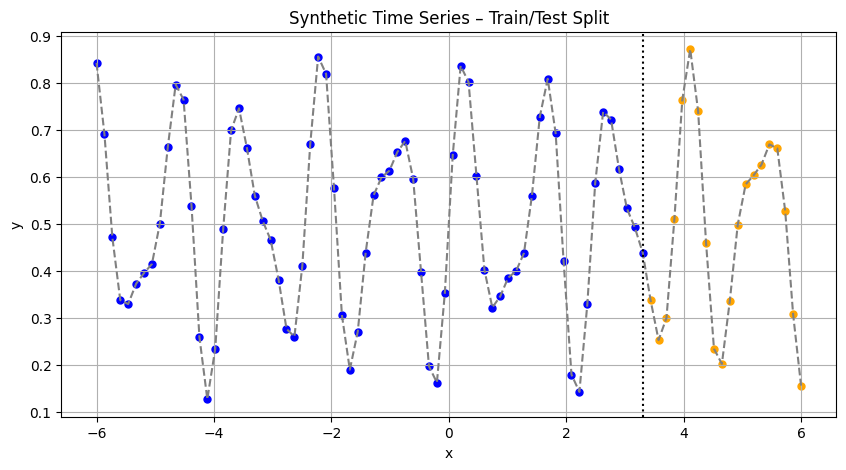

In [2]:
# ==== 1. Dane ====
x_all = np.linspace(-6, 6, 90)
y_all = (np.sin(5.0 * x_all) + 0.5 * np.sin(8.0 * x_all)) / 4 + 0.5

# ==== 2. Podział ====
x_train = x_all[:70]
y_train = y_all[:70]

x_test = x_all[70:]
y_test = y_all[70:]

# ==== 3. Wykres ====
plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, label="Target function", color="gray", linestyle="--")
plt.scatter(x_train, y_train, label="Train", color="blue", s=25)
plt.scatter(x_test, y_test, label="Test", color="orange", s=25)

# Linia podziału
plt.axvline(x=x_train[-1], color="black", linestyle=":", label="Train/Test split")

#plt.legend()
plt.title("Synthetic Time Series – Train/Test Split")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [3]:
dev = qml.device("default.qubit", wires=1)

scaling = 1

def S(x):
    """ kodowanie danych 
    x - wartosc skalarna jednej zmiennej - do przewidywania szeregow czasowych 
    czyli najczęściej to bedzie reprezentować oś czasu.
    scaling - trochę nie wiem po co ale zakładam, ze pozwoli ustalić zakres od 0 do 2pi bo kąty się powtarzają
    """
    qml.RX(scaling * x, wires=0)

def W(theta):
    """
    trenowalny blok zalezacy od 3 katów 
    wymusza aby theta bylo przynajmniej listą (krotką) posiadającą 3 elementy
    minimalny model z zaladowaniem danych [[1.2,0.3,4.5],[1.2,0.3,4.5]] - musi zawierac przynajmniej dwie listy
    """
    qml.Rot(theta[0], theta[1], theta[2], wires=0)

@qml.qnode(dev)
def serial_quantum_model(weights, x):
    for theta in weights[:-1]:
        W(theta)
        S(x)
    W(weights[-1])

    return qml.expval(qml.PauliZ(wires=0))

In [4]:
r = 4
weights = (np.random.random(size=(r+1, 3), requires_grad=True))

In [5]:
weights

tensor([[0.89089651, 0.25581115, 0.61948313],
        [0.04563328, 0.65239059, 0.98948203],
        [0.21453215, 0.63164529, 0.89463154],
        [0.27323252, 0.76256679, 0.9769891 ],
        [0.40788486, 0.05309109, 0.54035686]], requires_grad=True)

(<Figure size 1200x200 with 1 Axes>, <Axes: >)

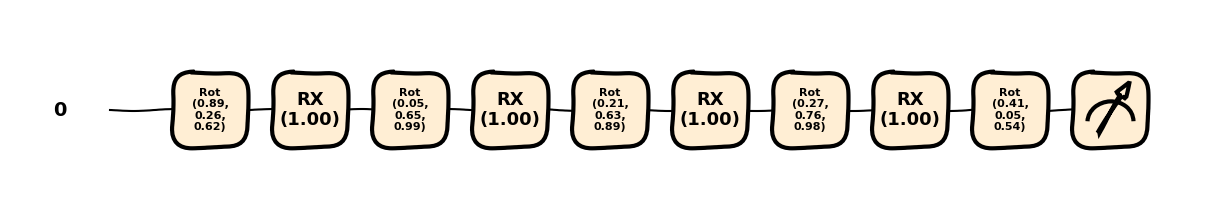

In [6]:
qml.draw_mpl(serial_quantum_model, decimals=2, level="device", style='sketch')(weights, 1.0)

In [7]:
X = np.linspace(-6,6, 200)
results = [serial_quantum_model(weights=weights, x=x_) for x_ in X]

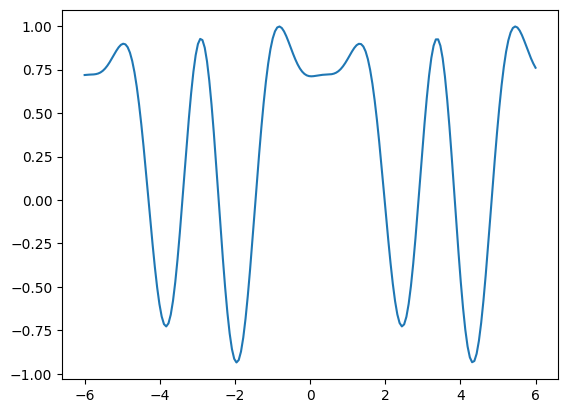

In [8]:
plt.plot(X,results)

In [9]:
# Koszt: MSE
def cost(weights, x_data, y_data):
    preds = np.array([serial_quantum_model(weights, x) for x in x_data])
    return np.mean((preds - y_data) ** 2)

r = 20
weights = (np.random.random(size=(r+1, 3), requires_grad=True))

# Optymalizacja
opt = qml.AdamOptimizer(stepsize=0.1)
epochs = 100

for epoch in range(epochs):
    weights = opt.step(lambda w: cost(w, x_train, y_train), weights)
    if epoch % 10 == 0:
        loss = cost(weights, x_train, y_train)
        print(f"Epoch {epoch}: loss = {loss:.6f}")


Epoch 0: loss = 0.291674
Epoch 10: loss = 0.072575
Epoch 20: loss = 0.016791
Epoch 30: loss = 0.011987
Epoch 40: loss = 0.007812
Epoch 50: loss = 0.004901
Epoch 60: loss = 0.003314
Epoch 70: loss = 0.002481
Epoch 80: loss = 0.001821
Epoch 90: loss = 0.001305


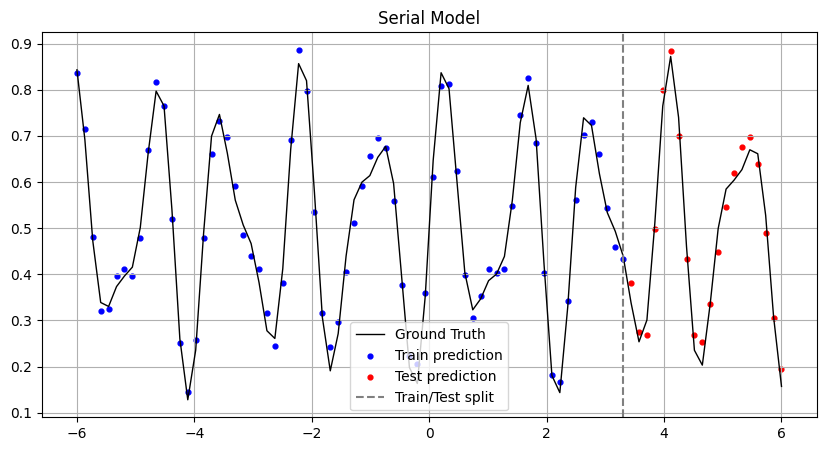

In [45]:
# Predykcje
y_pred_train = np.array([serial_quantum_model(weights, x ) for x in x_train])
y_pred_test = np.array([serial_quantum_model(weights, x) for x in x_test])

# Wykres
plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, label="Ground Truth", color="black", linewidth=1)
plt.scatter(x_train, y_pred_train, color="blue", label="Train prediction", s=12)
plt.scatter(x_test, y_pred_test, color="red", label="Test prediction", s=12)
plt.axvline(x=x_train[-1], color="gray", linestyle="--", label="Train/Test split")
plt.title("Serial Model")
plt.grid(True)
plt.legend()
plt.show()